In [12]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import storage_model
importlib.reload(storage_model)
from storage_model import Storage

STORAGE /SWING MODEL:

In [25]:
# Read Forward Curve
curve = pd.DataFrame(pd.read_csv("curve.csv"))
curve['contractStart'] = pd.to_datetime(curve['contractStart'], format='mixed')
curve['contractEnd'] = pd.to_datetime(curve['contractEnd'], format='mixed')

In [28]:
quotes = pd.read_csv("quotes.csv")
quotes.columns = quotes.columns.str.strip()
quotes['valDate'] = pd.to_datetime(quotes['valDate'], format='mixed', dayfirst=True)
quotes['Start'] = pd.to_datetime(quotes['Start'], format='mixed', dayfirst=True)
quotes['End'] = pd.to_datetime(quotes['End'], format='mixed', dayfirst=True)
quotes

,Product,market,valDate,Start,End,N_days,bid,ask,notes
0,xxx,TTF,2026-01-01,2026-01-01,2026-12-31,120,1.45,1.78,NaN
1,xxx,TTF,2026-01-01,2026-10-01,2027-09-30,180,0.40,0.80,NaN
2,xxx,TTF,2026-01-01,2026-01-01,2026-06-30,90,0.40,0.80,NaN
3,xxx,TTF,2026-01-01,2026-04-01,2026-09-30,90,0.73,0.80,NaN
4,xxx,TTF,2026-01-01,2026-04-01,2026-10-31,90,0.90,1.05,NaN
5,xxx,TTF,2026-01-01,2027-10-01,2028-09-30,180,0.60,0.85,NaN


In [29]:
quotes["model"] = 0.0
quotes["intrinsic"] = 0.0

for row in quotes.itertuples():

    valDate      = pd.Timestamp(row.valDate)
    storageStart = pd.Timestamp(row.Start)
    storageEnd   = pd.Timestamp(row.End)
    days         = int(row.N_days)

    s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=1000)
    s.build()
    flat_int = s.flat()
    print(f"flat = {s.flat():.2f}")


    # Intrinsic — start fully loaded
    s.set_volume_states(days)
    s.build()

    ProfiledEuro = s.v[0, 0, s.n_op_start]
    ACQ = np.sum(s.delta)

    intrinsic    = s.profiled() - flat_int
    print(f"Profiled price = {s.flat():.2f}")
    print(f"Intrinsic Value  = {intrinsic:.2f} on top of flat price")


    # Extrinsic — full price tree
    s.n_p = 30
    s.build()

    FullValueEuro = s.v[0, s.n_p, s.n_op_start]
    print(f"Extrinsic price = {FullValueEuro / ACQ:.2f}")
    ExtrValue = (FullValueEuro - ProfiledEuro) / ACQ
    print(f"Extrinsic Value = {ExtrValue:.2f}")
    print("")

    quotes.loc[row.Index, "intrinsic"] = float(intrinsic)
    quotes.loc[row.Index, "model"]     = float(ExtrValue)

flat = 27.53
Profiled price = 28.26
Intrinsic Value  = 0.73 on top of flat price
Extrinsic price = 29.33
Extrinsic Value = 1.07

flat = 26.55
Profiled price = 28.10
Intrinsic Value  = 1.55 on top of flat price
Extrinsic price = 28.79
Extrinsic Value = 0.69

flat = 27.58
Profiled price = 28.17
Intrinsic Value  = 0.59 on top of flat price
Extrinsic price = 28.29
Extrinsic Value = 0.13

flat = 27.02
Profiled price = 27.15
Intrinsic Value  = 0.13 on top of flat price
Extrinsic price = 27.81
Extrinsic Value = 0.65

flat = 27.09
Profiled price = 27.32
Intrinsic Value  = 0.23 on top of flat price
Extrinsic price = 28.16
Extrinsic Value = 0.84

flat = 24.75
Profiled price = 26.42
Intrinsic Value  = 1.68 on top of flat price
Extrinsic price = 27.07
Extrinsic Value = 0.65



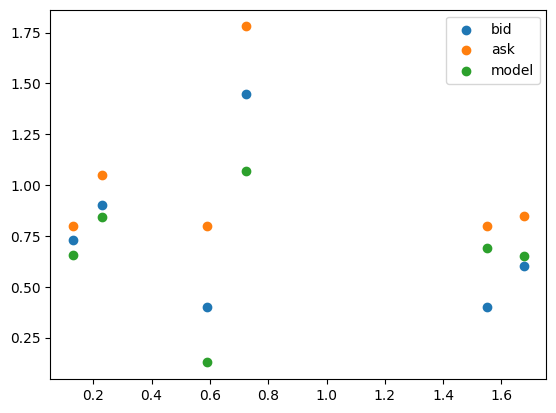

In [30]:
plt.scatter(quotes.intrinsic,quotes.bid,label='bid')
plt.scatter(quotes.intrinsic,quotes.ask,label='ask')
plt.scatter(quotes.intrinsic,quotes.model,label='model')
plt.legend()

Text(0.5, 1.0, 'Modelled Swing Premium vs Market Bids/Asks')

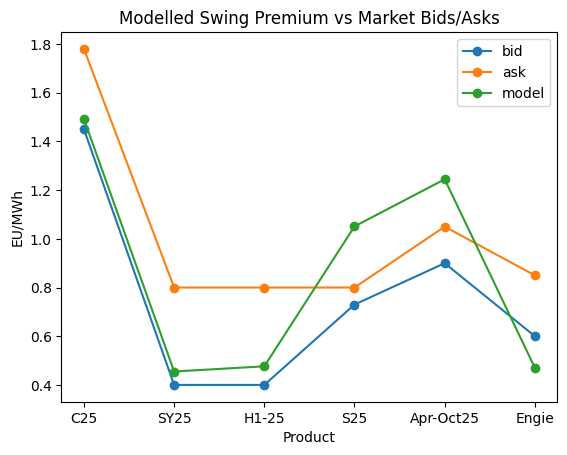

In [18]:
plt.plot(quotes.bid,'o-',label='bid')
plt.plot(quotes.ask,'o-',label='ask')
plt.plot(quotes.model,'o-',label='model')
plt.legend()
plt.xticks(ticks=range(len(quotes['Product'])), labels=quotes['Product'])
plt.ylabel("EU/MWh")
plt.xlabel("Product")
plt.title("Modelled Swing Premium vs Market Bids/Asks")